# Exploratory Data Analysis: PredictIt Market Data

This notebook analyzes the PredictIt prediction market data across three US Presidential Election cycles: 2016, 2020, and 2024.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sys
from pathlib import Path

sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 7)

import warnings
warnings.filterwarnings('ignore')

sys.path.append(str(Path('..').resolve()))
from bias_analysis.dataset import load_predictit_data

from loguru import logger
logger.remove()

2026-04-21 18:54:15.361 | INFO     | bias_analysis.config:<module>:11 - PROJ_ROOT path is: C:\Users\utente\Desktop\Work\TweetPollBias


## 1. Helper Functions

We need to filter the raw PredictIt data (which contains many contracts) to the main presidential candidates.

In [2]:
def get_candidate_prices(df, candidate_name):
    """Filter PredictIt data for a specific candidate substring match."""
    if df.empty: return pd.DataFrame()
    mask = df['Contract Name'].str.contains(candidate_name, case=False, na=False)
    return df[mask].sort_values('date')

def plot_market_trends(election_code, candidates, title):
    df = load_predictit_data(election_code)
    if df.empty:
        print(f"No data for {election_code}")
        return
    
    plt.figure()
    for cand in candidates:
        cand_df = get_candidate_prices(df, cand)
        if not cand_df.empty:
            plt.plot(cand_df['date'], cand_df['Close Share Price'], label=cand)
    
    plt.title(title)
    plt.ylabel('Share Price ($)')
    plt.xlabel('Date')
    plt.legend()
    plt.ylim(0, 1)
    plt.show()

## 2. 2016 Election Trends

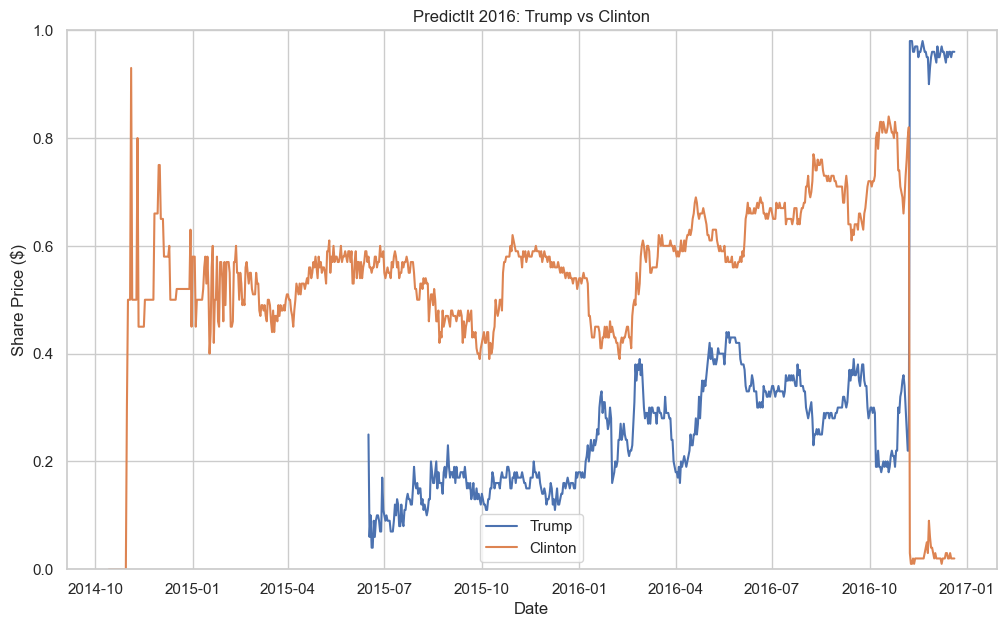

In [3]:
plot_market_trends("us16", ["Trump", "Clinton"], "PredictIt 2016: Trump vs Clinton")

## 3. 2020 Election Trends

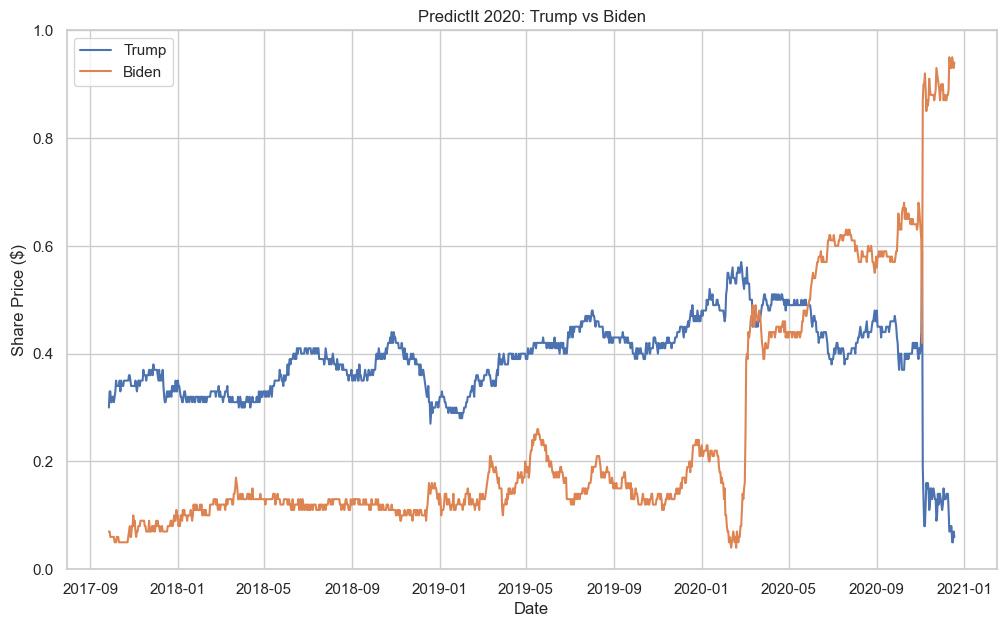

In [4]:
plot_market_trends("us20", ["Trump", "Biden"], "PredictIt 2020: Trump vs Biden")

## 4. 2024 Election Trends

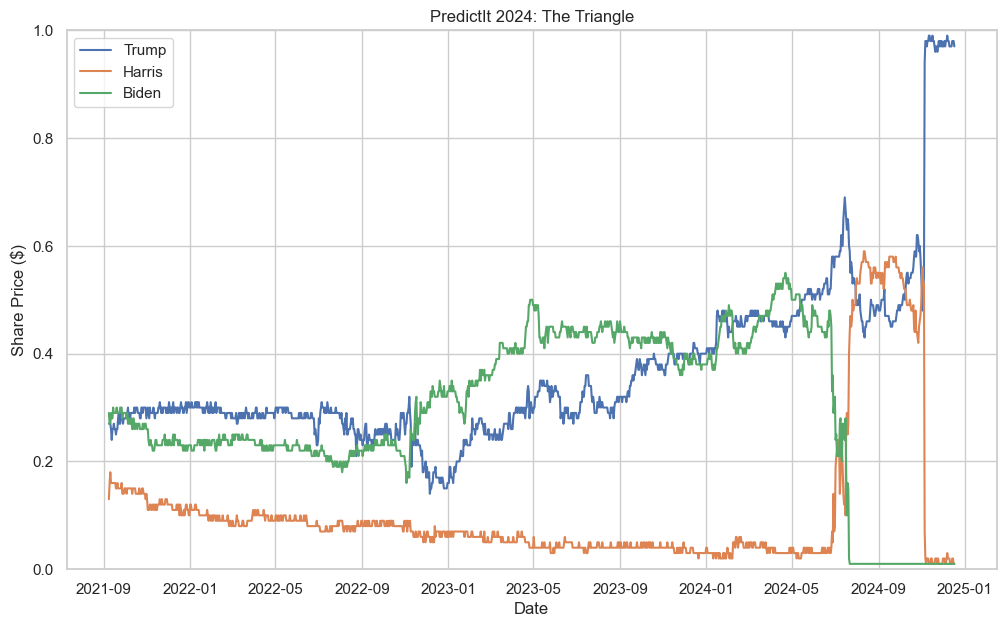

In [5]:
plot_market_trends("us24", ["Trump", "Harris", "Biden"], "PredictIt 2024: The Triangle")

## 5. Volatility Comparison

How volatile was each election in the final 100 days?

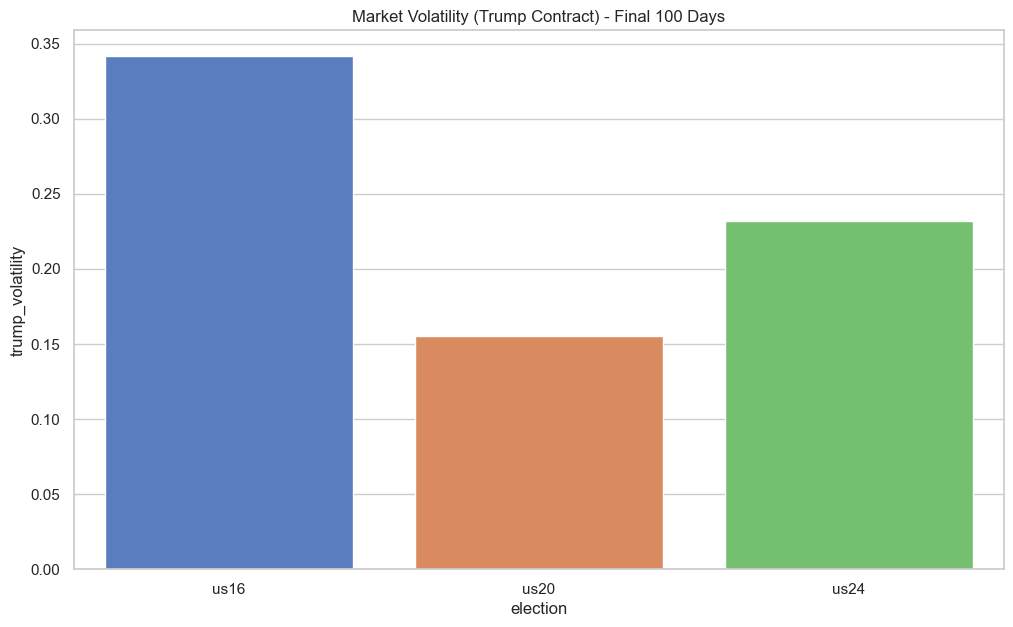

In [6]:
stats = []
for election in ["us16", "us20", "us24"]:
    df = load_predictit_data(election)
    if df.empty: continue
    
    # Take late campaign data
    end_date = df['date'].max()
    late_df = df[df['date'] > end_date - pd.Timedelta(days=100)]
    
    # Standard deviation of close prices for main candidate (Trump is in all)
    trump_df = get_candidate_prices(late_df, "Trump")
    if not trump_df.empty:
        vol = trump_df['Close Share Price'].std()
        stats.append({"election": election, "trump_volatility": vol})

vol_df = pd.DataFrame(stats)
sns.barplot(data=vol_df, x="election", y="trump_volatility", palette="muted")
plt.title("Market Volatility (Trump Contract) - Final 100 Days")
plt.show()